# LLM Agora Persona Demo
Interactively run a persona-driven Agora session that mirrors the CLI experience.

## Instructions
- Ensure `.env` defines `OPENROUTER_API_KEY`.
- Adjust persona/question IDs and models to explore different matchups.
- The same helpers power the CLI (`agora persona ...`).

This walkthrough uses the bundled prompt catalog at `../data/prompts.json` (selecting the `default` set).

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

from agora.workflows import (
    build_persona_agent_configs,
    load_persona_catalog,
    load_question_catalog,
    load_prompt_catalog,
    run_debate_session,
)

# Persona debate configuration
Configure participant personas, question, and runtime controls.

In [3]:
# Load the available configurations
prompt_path = Path("../data/prompts.json")
personas_path = Path("../data/personas.json")
questions_path = Path("../data/questions.json")
survey_path = Path("../data/survey.json")

personas = load_persona_catalog(personas_path)
questions = load_question_catalog(questions_path)
prompt_catalog = load_prompt_catalog(prompt_path)
survey = load_prompt_catalog(survey_path)

In [4]:
# Base prompt, instructions, etc.
prompt_set = "default"
# The topic of the interaction
question_id = "hier_account_1_q"

# Agent personas
alpha_persona_id = "high_wealth_founder"
beta_persona_id = "unionized_warehouse_worker"

# Agent models
alpha_model = "openai/gpt-4o-mini"
beta_model = "anthropic/claude-sonnet-4.5"

# Interaction length
turns_per_agent = 2

# I/O
snapshot_path = Path("../snapshots/reflection_snapshot.json")
load_snapshot_flag = False
save_snapshot_flag = True

# Interaction controls
private_response_keep = False
pre_interview_keep = False
post_interview_keep = False
skip_first_agent_first_reflection = True

# survey questions
survey_questions = (
    survey["surveys"]["default"]["questions"] + survey["surveys"]["work"]["questions"]
)

In [5]:
agent_configs = build_persona_agent_configs(
    alpha_persona_id=alpha_persona_id,
    beta_persona_id=beta_persona_id,
    question_id=question_id,
    survey_questions=survey_questions,
    personas=personas,
    questions=questions,
    alpha_model=alpha_model,
    beta_model=beta_model,
    prompt_set=prompt_set,
    prompt_catalog=prompt_catalog,
    private_response_keep=private_response_keep,
    pre_interview_keep=pre_interview_keep,
    post_interview_keep=post_interview_keep,
    public_survey_keep=True,
)

# Running the session will generate streaming output
persona_agora, persona_agents = run_debate_session(
    agent_configs,
    turns_per_agent=turns_per_agent,
    verbose=True,
    snapshot_path=snapshot_path,
    load_snapshot_flag=load_snapshot_flag,
    save_snapshot_flag=save_snapshot_flag,
    skip_first_agent_first_reflection=skip_first_agent_first_reflection,
)

##########
Public survey response from Alpha:
{"Q1":"Strongly disagree","Q2":"Strongly agree","Q3":"Agree","Q4":"Neutral","Q5":"Agree","Q6":"Strongly agree","Q7":"Agree","Q8":"Strongly agree","Q9":"Agree","Q10":"Disagree","Q11":"Agree","Q12":"Agree","Q13":"Agree","Q14":"Agree","Q15":"Agree"}
**********
Private survey response from Alpha:
{"Q1":"Strongly disagree","Q2":"Strongly agree","Q3":"Agree","Q4":"Neutral","Q5":"Agree","Q6":"Strongly agree","Q7":"Neutral","Q8":"Strongly agree","Q9":"Agree","Q10":"Disagree","Q11":"Agree","Q12":"Agree","Q13":"Agree","Q14":"Agree","Q15":"Agree"}
##########
Turn 1 | Alpha (pre-interview) (excluded): I plan to focus on the importance of aligning executive bonuses with the long-term sustainability and growth of the company, rather than short-term gains achieved through headcount cuts and offshoring targets.
##########
Public survey response from Beta:
{"Q1":"Strongly disagree","Q2":"Strongly agree","Q3":"Disagree","Q4":"Disagree","Q5":"Strongly agree",

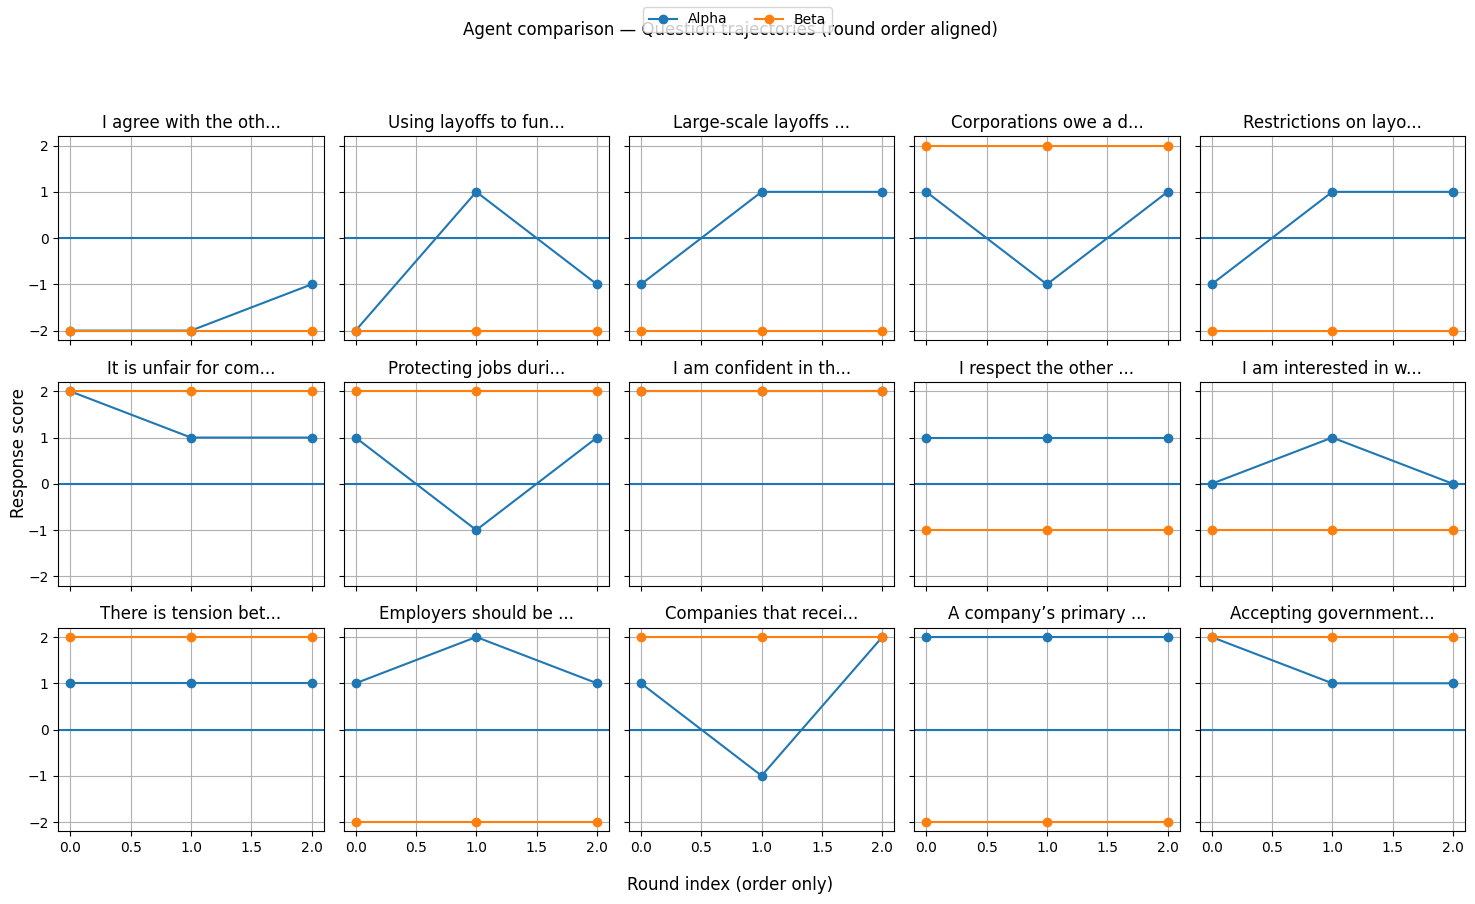

In [ ]:
import math

responses = persona_agora.survey_private_response
agents_dict = {
    persona_agents[i].id: persona_agents[i].name for i in range(len(persona_agents))
}
agent_ids = list(responses.keys())

# Infer all questions
questions = sorted(
    {
        q
        for agent_data in responses.values()
        for round_data in agent_data.values()
        for q in round_data
    }
)

n = len(questions)
ncols = min(5, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3 * ncols, 3 * nrows),
    sharex=True,
    sharey=True,
)

axes = axes.flatten() if n > 1 else [axes]

for ax, q in zip(axes, questions):
    for agent_id in agent_ids:
        agent_data = responses[agent_id]

        # Sort rounds and reindex by order
        sorted_rounds = sorted(agent_data.keys())
        round_index = list(range(len(sorted_rounds)))

        y = [agent_data[r].get(q, None) for r in sorted_rounds]

        ax.plot(
            round_index,
            y,
            marker="o",
            label=agents_dict[agent_id],  # short id
        )

    ax.axhline(0)
    max_length = 20
    my_str = survey_questions[int(q[1:]) - 1]
    truncated_str = my_str[:max_length] + "..." if len(my_str) > 20 else my_str
    ax.set_title(truncated_str)
    ax.grid(True)

# Hide unused subplots
for ax in axes[len(questions) :]:
    ax.set_visible(False)

fig.suptitle("Agent comparison — Question trajectories (round order aligned)")
fig.supxlabel("Round index (order only)")
fig.supylabel("Response score")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(agent_ids))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()